In [ ]:
# import required (all) libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORT DATA & READ DATA

In [ ]:
df = pd.read_csv("Walmart.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


# CLEANING DATA

In [ ]:
df.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Date"].isna().sum()

np.int64(0)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format='%d-%m-%Y')
df["Date"]

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
6430,2012-09-28
6431,2012-10-05
6432,2012-10-12
6433,2012-10-19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [ ]:
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week.astype(int)

In [ ]:
# list the data
df = df.sort_values(["Store","Date"]).reset_index(drop=True)
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,39
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,40
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,41
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,42


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   year          6435 non-null   int32         
 9   month         6435 non-null   int32         
 10  week          6435 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int32(2), int64(3)
memory usage: 502.9 KB


# HOLIDAY IMPACT

In [ ]:
# Mean sales holiday vs non-holiday
df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


In [ ]:
# avg sales each store (holiday vs non holiday)
avg_sales = (df.groupby(["Store", "Holiday_Flag"])["Weekly_Sales"].mean().reset_index())

avg_pivot = avg_sales.pivot(index="Store", columns="Holiday_Flag", values="Weekly_Sales")
avg_pivot = avg_pivot.rename(columns={0: "Avg_NonHoliday", 1: "Avg_Holiday"})
avg_pivot

Holiday_Flag,Avg_NonHoliday,Avg_Holiday
Store,,
1,1.546957e+06,1665747.656
2,1.914209e+06,2079266.900
3,4.000648e+05,437811.050
4,2.083556e+06,2243102.624
5,3.148923e+05,359501.607
6,1.555993e+06,1680907.927
7,5.629645e+05,672400.265
8,9.037434e+05,975330.860
9,5.405993e+05,588950.821


In [ ]:
avg_pivot["uplift"] = avg_pivot["Avg_Holiday"] - avg_pivot["Avg_NonHoliday"]
avg_pivot["uplift_pct"] = (avg_pivot["uplift"] / avg_pivot["Avg_NonHoliday"]) * 100

top10 = avg_pivot.sort_values("uplift_pct", ascending=False).head(10)
top10

Holiday_Flag,Avg_NonHoliday,Avg_Holiday,uplift,uplift_pct
Store,,,,
7,5.629645e+05,672400.265,109435.810188,19.439204
35,9.080992e+05,1074348.457,166249.302789,18.307395
15,6.170648e+05,706406.018,89341.177850,14.478410
5,3.148923e+05,359501.607,44609.330083,14.166537
12,9.992919e+05,1138140.420,138848.495564,13.894688
29,5.343758e+05,606957.889,72582.133962,13.582602
28,1.311889e+06,1478244.605,166355.623571,12.680617
10,1.883309e+06,2113755.949,230446.517421,12.236254
17,8.870990e+05,979796.971,92697.955060,10.449561


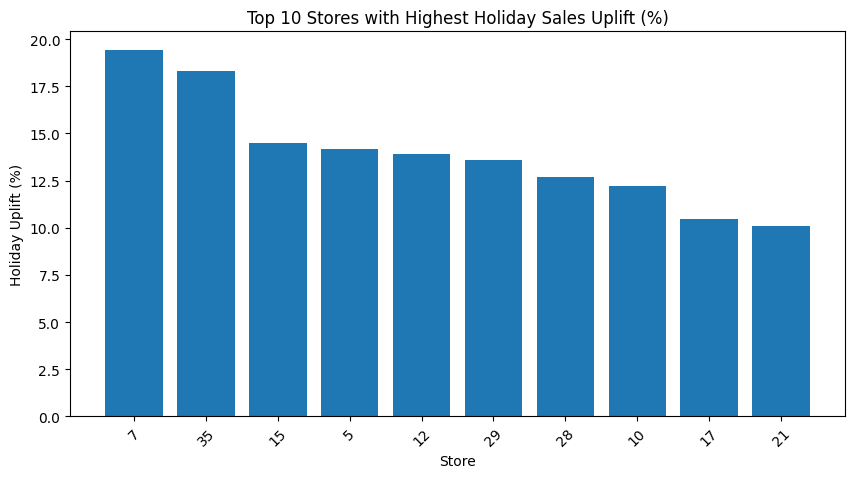

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top10.index.astype(str), top10["uplift_pct"])
plt.xlabel("Store")
plt.ylabel("Holiday Uplift (%)")
plt.title("Top 10 Stores with Highest Holiday Sales Uplift (%)")
plt.xticks(rotation=45)
plt.show()

The chart shows that holiday periods significantly increase sales across Walmart stores, with some stores experiencing up to 20% growth. However, the impact varies between stores, indicating differences in customer demand and store characteristics. This suggests that holiday effects are not uniform and that targeted strategies should be applied to maximize sales performance.


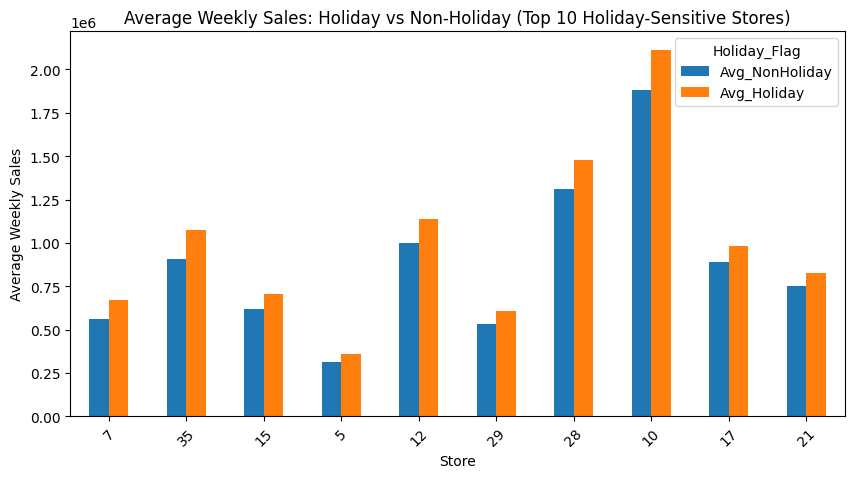

In [ ]:
top10_plot = top10[["Avg_NonHoliday", "Avg_Holiday"]].copy()

top10_plot.plot(kind="bar", figsize=(10,5))
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.title("Average Weekly Sales: Holiday vs Non-Holiday (Top 10 Holiday-Sensitive Stores)")
plt.xticks(rotation=45)
plt.show()

The chart shows that average weekly sales are consistently higher during holiday periods across all selected stores. This confirms that holidays significantly boost consumer spending. The gap between holiday and non-holiday sales varies by store, indicating that some stores are more responsive to holiday demand, which suggests the need for targeted sales and inventory strategies.

#PREDICT WEEKLY SALES


In [ ]:
df.shape

(6435, 11)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Import data
df = pd.read_csv('Walmart.csv')

# Convert dates to numerical
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Week'] = df['Date'].dt.isocalendar().week

# Dropp column date for the model
df_model = df.drop(['Date'], axis=1)

In [ ]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year', 'Week'],
      dtype='object')

In [ ]:
X = df_model.drop('Weekly_Sales', axis=1)
y = df_model['Weekly_Sales']

# Divide data in train and test (80,20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Build model and train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Realizar predicciones
predictions = model.predict(X_test)

In [ ]:
# Evaluate the model using an appropriate regression metric (e.g., R-squared)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Absolute Error: 62122.37653644132
R-squared: 0.9595284870090277


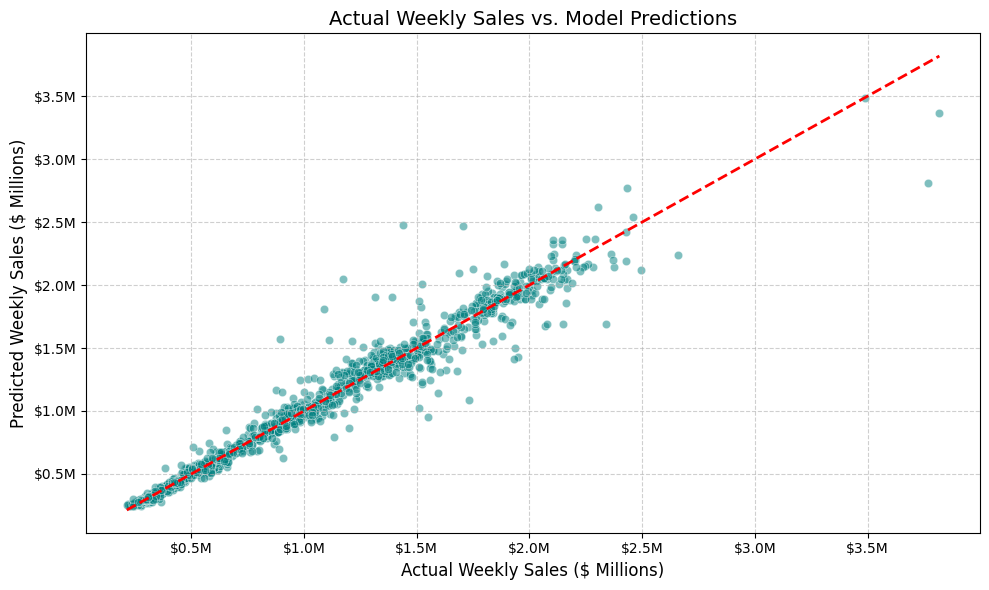

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Define a function to format the numbers as Millions
def millions_formatter(x, pos):
    return f'${x*1e-6:.1f}M'

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.5, color='teal')

# Draw the "Perfect Prediction" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

# APPLY FORMATTING TO AXES
formatter = FuncFormatter(millions_formatter)
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Actual Weekly Sales vs. Model Predictions', fontsize=14)
plt.xlabel('Actual Weekly Sales ($ Millions)', fontsize=12)
plt.ylabel('Predicted Weekly Sales ($ Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The scatter plot shows a strong alignment between actual and predicted values, indicating that the model performs very well. Most points are close to the diagonal line, confirming high prediction accuracy, which is supported by the high R² value (≈ 0.96). However, slight deviations at higher sales levels suggest that the model is less precise for extreme values.


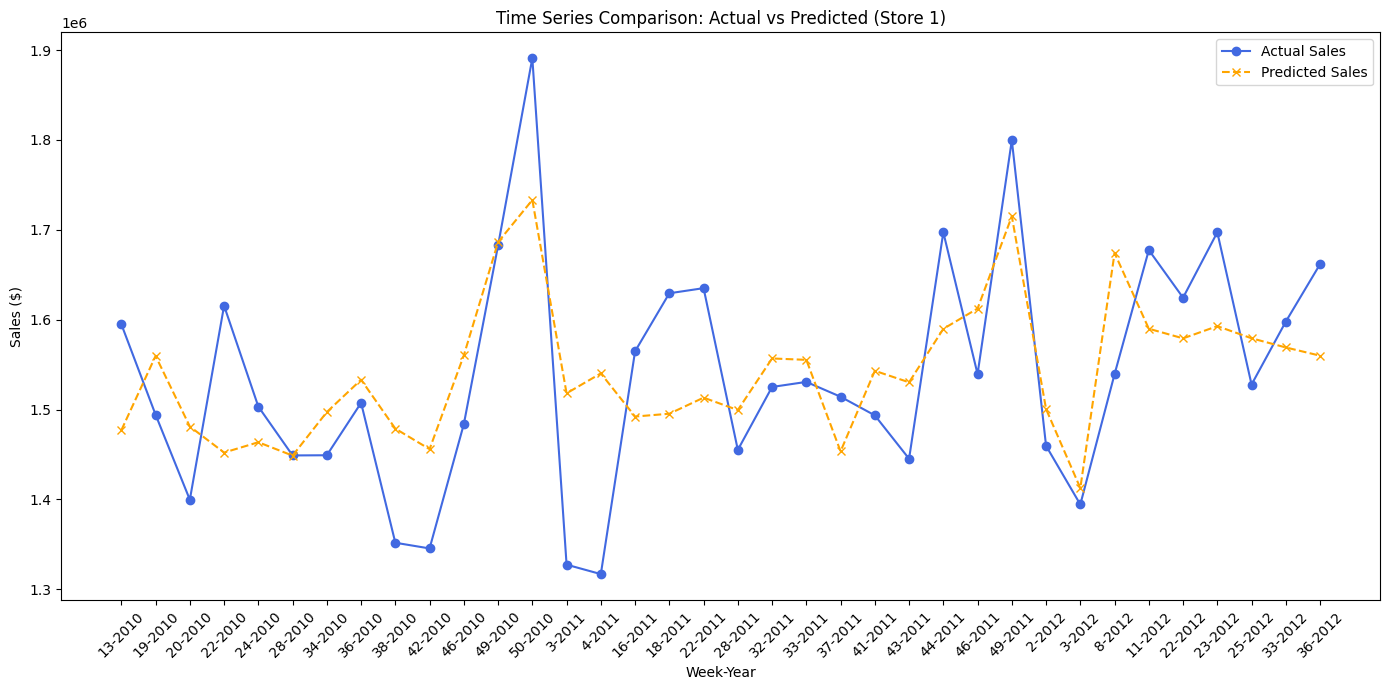

In [ ]:
# 1. Create a DataFrame with the test set results
results = X_test.copy()
results['Actual_Sales'] = y_test
results['Predictions'] = predictions

# 2. Filter for a specific store to make the chart readable (e.g., Store 1)
# and sort by Year and Week
store_1_data = results[results['Store'] == 1].sort_values(by=['Year', 'Week'])

# 3. Generate the Time Series Plot
plt.figure(figsize=(14, 7))
plt.plot(store_1_data['Week'].astype(str) + "-" + store_1_data['Year'].astype(str),
         store_1_data['Actual_Sales'], label='Actual Sales', marker='o', color='royalblue')
plt.plot(store_1_data['Week'].astype(str) + "-" + store_1_data['Year'].astype(str),
         store_1_data['Predictions'], label='Predicted Sales', marker='x', linestyle='--', color='orange')

plt.xticks(rotation=45)
plt.title('Time Series Comparison: Actual vs Predicted (Store 1)')
plt.xlabel('Week-Year')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

The time series shows that predicted sales closely follow the actual sales trend, capturing overall patterns effectively. However, the model smooths extreme fluctuations, slightly underestimating peaks and overestimating drops. This indicates good general performance but limited accuracy in capturing sudden variations.

# TOP 3 WEEKLY SALES

In [ ]:
import pandas as pd

df = pd.read_csv('Walmart.csv')

# Grouping by Store and summing Weekly_Sales to find total income per store
top_3_income = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(3).reset_index()
top_3_income.columns = ['Store', 'Total_Income']

print('Top 3 Stores by Total Income:')
display(top_3_income)

Top 3 Stores by Total Income:


,Store,Total_Income
0,20,3.013978e+08
1,4,2.995440e+08
2,14,2.889999e+08


The results show that Stores 20, 4, and 14 generate the highest total sales, making them the top-performing stores. This indicates that these locations have stronger demand and better overall performance compared to others, highlighting their importance for revenue generation.

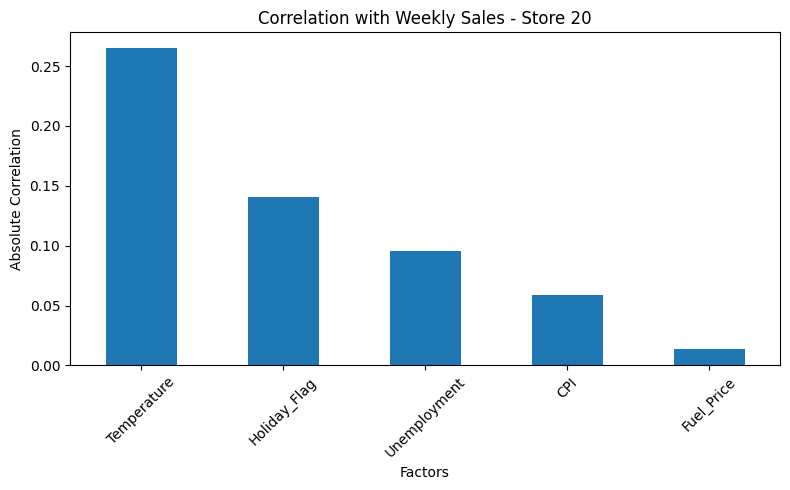

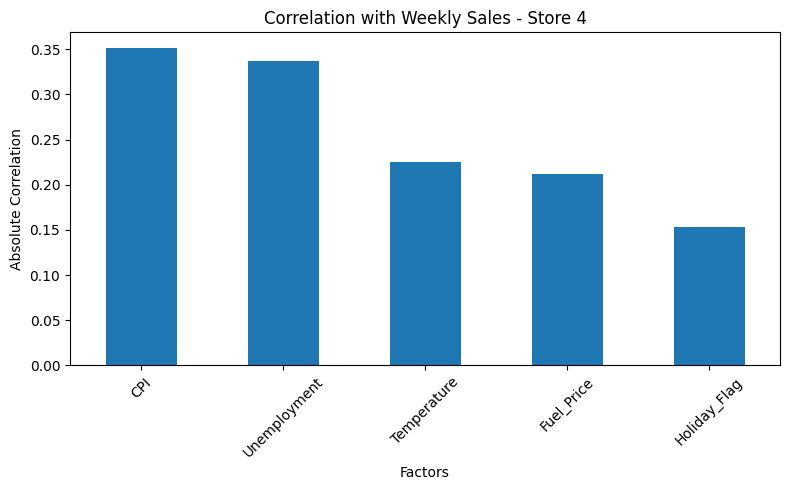

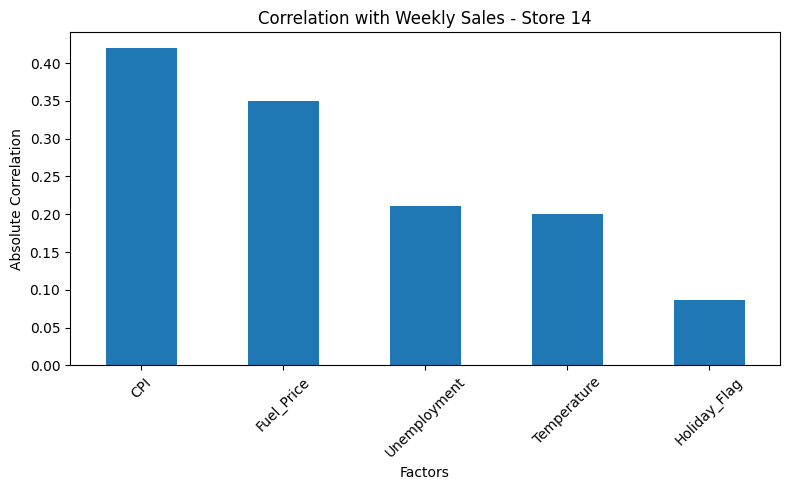

In [ ]:
for store in top_3_income['Store']:
    store_df = df[df['Store'] == store]
    corr = store_df[['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()['Weekly_Sales'].drop('Weekly_Sales')
    corr = corr.abs().sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    corr.plot(kind='bar')
    plt.title(f'Correlation with Weekly Sales - Store {store}')
    plt.ylabel('Absolute Correlation')
    plt.xlabel('Factors')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The results show that Stores 20, 4, and 14 generate the highest total sales, making them the most profitable locations. The correlation analysis indicates that economic factors such as CPI and fuel price have a stronger influence on sales than holiday effects. This suggests that macroeconomic conditions play a key role in driving sales performance in top stores.